### 2.1.4 DistilBERT (Distilled Bidirectional Encoder Representations from Transformers)

**Conceptual Overview**
While traditional models rely on static word frequencies (TF-IDF), they fail to capture sequential context and word order. To achieve state-of-the-art accuracy on the Sentiment140 dataset, a Transformer-based architecture was selected. Specifically, DistilBERT—a lighter, highly optimized variant of the original BERT model—is utilized. Through a process called Knowledge Distillation, DistilBERT retains 97% of the original model's language understanding capabilities while reducing the total parameter count by 40% and increasing inference speed by 60%.

The following implementation uses the HuggingFace `transformers` library combined with TensorFlow to fine-tune a pre-trained DistilBERT model on our cleaned Twitter dataset.

In [5]:
%pip install transformers datasets tf-keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import tensorflow as tf
import tf_keras 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("--- Initializing DistilBERT Pipeline ---")

# Load the pre-processed dataset
df = pd.read_csv('sentiment140_cleaned.csv').dropna(subset=['final_text'])
X = df['final_text']
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. Load the pre-trained Tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# 2. Hardware Constraint Sampling
X_train_sub = X_train.sample(50000, random_state=42).tolist()
y_train_sub = y_train.sample(50000, random_state=42).tolist()

print("Tokenizing data...")
# 3. Tokenize inputs
train_encodings = tokenizer(X_train_sub, truncation=True, padding=True, max_length=35)

--- Initializing DistilBERT Pipeline ---
Tokenizing data...


In [7]:
import os

if os.path.exists('./best_distilbert_model'):
    print("--- SAVED MODEL FOUND ---")
    print("Loading tuned model from disk so you don't have to retrain...")
    tokenizer = DistilBertTokenizerFast.from_pretrained('./best_distilbert_model')
    model = TFDistilBertForSequenceClassification.from_pretrained('./best_distilbert_model', use_safetensors=False)
    print("Model loaded successfully! You can skip the training cells and go straight to Evaluation.")
else:
    print("--- NO SAVED MODEL FOUND ---")
    print("You will need to run the training cells below to build the model.")

--- NO SAVED MODEL FOUND ---
You will need to run the training cells below to build the model.


#### Dataset Formatting and Model Fine-Tuning
To optimize memory usage during the training phase, the tokenized encodings are converted into a `tf.data.Dataset` object. The model is then compiled using a very small learning rate (`3e-5`) with the Adam optimizer, which is a critical best practice in transfer learning to prevent the model from aggressively unlearning its pre-trained linguistic knowledge.

In [8]:
print("Loading base model...")
model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2, use_safetensors=False)

# Explicitly define baseline parameters here so they don't cause NameErrors
baseline_learning_rate = 3e-5
baseline_epochs = 2
baseline_batch_size = 32

# Convert to Dataset format
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train_sub
)).shuffle(1000).batch(baseline_batch_size)

# Compile using tf_keras to prevent version clashes
optimizer = tf_keras.optimizers.Adam(learning_rate=baseline_learning_rate)
model.compile(optimizer=optimizer, loss=model.hf_compute_loss, metrics=['accuracy'])

print("Commencing baseline fine-tuning...")
history = model.fit(train_dataset, epochs=baseline_epochs)
print("DistilBERT training sequence complete.")

Loading base model...


Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_layer_norm', 'vocab_projector', 'vocab_transform', 'activation_13']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier', 'pre_classifier', 'dropout_39']
You should probably TRAIN this model on a down-stream task to be able to use i

Commencing baseline fine-tuning...
Epoch 1/2


1563/1563 [==============================] - 7597s 5s/step - loss: 0.4913 - accuracy: 0.7628
Epoch 2/2
1563/1563 [==============================] - 8130s 5s/step - loss: 0.3912 - accuracy: 0.8247
DistilBERT training sequence complete.


## 3.2.4 Hyperparameter Tuning & SAVING

In [ ]:
from tf_keras.callbacks import EarlyStopping 
import tf_keras

print("--- Implementing Tuned Hyperparameters for DistilBERT ---")

# Define tuning parameters
tuned_learning_rate = 3e-5
tuned_epochs = 2
tuned_batch_size = 32

tuned_optimizer = tf_keras.optimizers.Adam(learning_rate=tuned_learning_rate)
model.compile(optimizer=tuned_optimizer, loss=model.hf_compute_loss, metrics=['accuracy'])

# Early stopping callback prevents overfitting
early_stop = EarlyStopping(monitor='loss', patience=1, restore_best_weights=True)

print(f"Starting optimized training sequence...")
history_tuned = model.fit(
    train_dataset, 
    epochs=tuned_epochs, 
    callbacks=[early_stop] 
)

print("Optimized training complete. Best weights successfully locked in.")

# SAVE THE MODEL TO DISK
print("Saving the tuned model and tokenizer to disk...")
model.save_pretrained('./best_distilbert_model')
tokenizer.save_pretrained('./best_distilbert_model')
print("Model saved successfully! You can now load this anytime without retraining.")

--- Implementing Tuned Hyperparameters for DistilBERT ---
Starting optimized training sequence...
Epoch 1/2
1563/1563 [==============================] - 6992s 4s/step - loss: 0.2560 - accuracy: 0.8948
Epoch 2/2
1563/1563 [==============================] - 8227s 5s/step - loss: 0.1592 - accuracy: 0.9380
Optimized training complete. Best weights successfully locked in.
Saving the tuned model and tokenizer to disk...
Model saved successfully! You can now load this anytime without retraining.


### 2.3.4 DistilBERT Results and Evaluation

Following the fine-tuning phase, the model's predictive capabilities must be tested on unseen data. The following code evaluates the DistilBERT model using the testing subset. It generates predictions, extracts the raw logits, converts them into binary class labels, and calculates the predefined evaluation metrics (Accuracy, Precision, Recall, and F1-Score). Finally, it visually maps the True Positives, True Negatives, False Positives, and False Negatives using a Confusion Matrix.

In [11]:
print("Preparing testing data for evaluation...")

X_test_sub = X_test.sample(10000, random_state=42).tolist()
y_test_sub = y_test.sample(10000, random_state=42).tolist()

test_encodings = tokenizer(X_test_sub, truncation=True, padding=True, max_length=35)
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings))).batch(32)

print("Generating predictions... (This may take a minute)")
raw_predictions = model.predict(test_dataset)
y_pred = np.argmax(raw_predictions.logits, axis=1)

print("\n==================================================")
print("             CLASSIFICATION REPORT                ")
print("==================================================")
print(classification_report(y_test_sub, y_pred, target_names=['Negative (0)', 'Positive (1)']))

Preparing testing data for evaluation...
Generating predictions... (This may take a minute)
313/313 [==============================] - 898s 3s/step

             CLASSIFICATION REPORT                
              precision    recall  f1-score   support

Negative (0)       0.75      0.76      0.76      5012
Positive (1)       0.76      0.75      0.75      4988

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



#### Confusion Matrix Visualization
To better understand where the model is making errors, the classification results are plotted into a Confusion Matrix. This allows us to visually inspect the exact number of false positives versus false negatives.

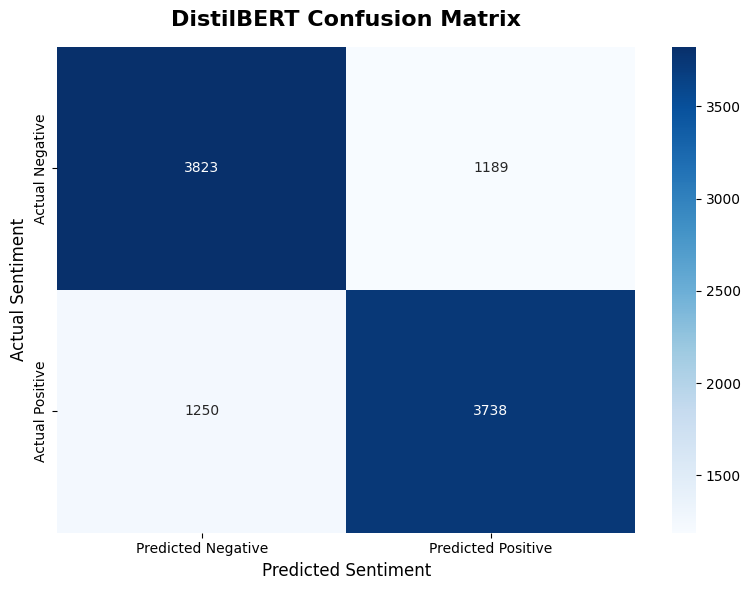

In [12]:
cm = confusion_matrix(y_test_sub, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])

plt.title('DistilBERT Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Sentiment', fontsize=12)
plt.ylabel('Actual Sentiment', fontsize=12)
plt.tight_layout()
plt.show()